<h1>CELL 1 — Install packages </h1>

In [5]:
import subprocess, sys
packages = ["ultralytics","opencv-python","numpy","filterpy","scipy","Pillow","matplotlib","lapx","ipykernel","jupyter"]
for pkg in packages:
    subprocess.check_call([sys.executable, "-m", "pip", "install", pkg, "-q"])
print("✅ Done!")

✅ Done!


<h1>CELL 2 — All imports + SORT tracker</h1>

In [6]:
import cv2, numpy as np, time, os, urllib.request, warnings
from ultralytics import YOLO
from collections import defaultdict
from filterpy.kalman import KalmanFilter
from scipy.optimize import linear_sum_assignment
import matplotlib.pyplot as plt
from IPython.display import display, Image as IPImage, clear_output
warnings.filterwarnings('ignore')

# ── SORT helper functions ──
def convert_bbox_to_z(bbox):
    w = bbox[2]-bbox[0]; h = bbox[3]-bbox[1]
    return np.array([bbox[0]+w/2., bbox[1]+h/2., w*h, w/float(h) if h else 1.]).reshape((4,1))

def convert_x_to_bbox(x, score=None):
    w = np.sqrt(abs(x[2]*x[3])); h = x[2]/w if w else 0
    box = [x[0]-w/2., x[1]-h/2., x[0]+w/2., x[1]+h/2.]
    return np.array(box).reshape((1,4)) if score is None else np.array([*box, score]).reshape((1,5))

def iou_batch(bb_test, bb_gt):
    bb_gt = np.expand_dims(bb_gt,0); bb_test = np.expand_dims(bb_test,1)
    xx1=np.maximum(bb_test[...,0],bb_gt[...,0]); yy1=np.maximum(bb_test[...,1],bb_gt[...,1])
    xx2=np.minimum(bb_test[...,2],bb_gt[...,2]); yy2=np.minimum(bb_test[...,3],bb_gt[...,3])
    inter=np.maximum(0.,xx2-xx1)*np.maximum(0.,yy2-yy1)
    area_t=(bb_test[...,2]-bb_test[...,0])*(bb_test[...,3]-bb_test[...,1])
    area_g=(bb_gt[...,2]-bb_gt[...,0])*(bb_gt[...,3]-bb_gt[...,1])
    return inter/(area_t+area_g-inter+1e-6)

def associate_detections_to_trackers(detections, trackers, iou_threshold=0.3):
    if len(trackers)==0:
        return np.empty((0,2),dtype=int), np.arange(len(detections)), np.empty((0,5),dtype=int)
    iou_matrix = iou_batch(detections, trackers)
    if min(iou_matrix.shape)>0:
        a=(iou_matrix>iou_threshold).astype(np.int32)
        if a.sum(1).max()==1 and a.sum(0).max()==1:
            matched_indices=np.stack(np.where(a),axis=1)
        else:
            r,c=linear_sum_assignment(-iou_matrix); matched_indices=np.stack([r,c],axis=1)
    else:
        matched_indices=np.empty(shape=(0,2))
    unmatched_dets=[d for d in range(len(detections)) if d not in matched_indices[:,0]] if len(matched_indices) else list(range(len(detections)))
    unmatched_trks=[t for t in range(len(trackers))  if t not in matched_indices[:,1]] if len(matched_indices) else list(range(len(trackers)))
    matches=[]
    for m in matched_indices:
        if iou_matrix[m[0],m[1]]<iou_threshold:
            unmatched_dets.append(m[0]); unmatched_trks.append(m[1])
        else:
            matches.append(m.reshape(1,2))
    matches=np.concatenate(matches,axis=0) if matches else np.empty((0,2),dtype=int)
    return matches, np.array(unmatched_dets), np.array(unmatched_trks)

class KalmanBoxTracker:
    count=0
    def __init__(self,bbox):
        self.kf=KalmanFilter(dim_x=7,dim_z=4)
        self.kf.F=np.array([[1,0,0,0,1,0,0],[0,1,0,0,0,1,0],[0,0,1,0,0,0,1],
                             [0,0,0,1,0,0,0],[0,0,0,0,1,0,0],[0,0,0,0,0,1,0],[0,0,0,0,0,0,1]])
        self.kf.H=np.array([[1,0,0,0,0,0,0],[0,1,0,0,0,0,0],[0,0,1,0,0,0,0],[0,0,0,1,0,0,0]])
        self.kf.R[2:,2:]*=10.; self.kf.P[4:,4:]*=1000.; self.kf.P*=10.
        self.kf.Q[-1,-1]*=0.01; self.kf.Q[4:,4:]*=0.01
        self.kf.x[:4]=convert_bbox_to_z(bbox)
        self.time_since_update=0; self.id=KalmanBoxTracker.count
        KalmanBoxTracker.count+=1; self.history=[]; self.hits=0; self.hit_streak=0; self.age=0
    def update(self,bbox):
        self.time_since_update=0; self.history=[]; self.hits+=1; self.hit_streak+=1
        self.kf.update(convert_bbox_to_z(bbox))
    def predict(self):
        if (self.kf.x[6]+self.kf.x[2])<=0: self.kf.x[6]*=0.0
        self.kf.predict(); self.age+=1
        if self.time_since_update>0: self.hit_streak=0
        self.time_since_update+=1
        self.history.append(convert_x_to_bbox(self.kf.x))
        return self.history[-1]
    def get_state(self): return convert_x_to_bbox(self.kf.x)

class Sort:
    def __init__(self,max_age=5,min_hits=2,iou_threshold=0.3):
        self.max_age=max_age; self.min_hits=min_hits
        self.iou_threshold=iou_threshold; self.trackers=[]; self.frame_count=0
    def update(self,dets=np.empty((0,5))):
        self.frame_count+=1
        trks=np.zeros((len(self.trackers),5)); to_del=[]
        for t,trk in enumerate(trks):
            pos=self.trackers[t].predict()[0]
            trk[:]=[pos[0],pos[1],pos[2],pos[3],0]
            if np.any(np.isnan(pos)): to_del.append(t)
        trks=np.ma.compress_rows(np.ma.masked_invalid(trks))
        for t in reversed(to_del): self.trackers.pop(t)
        matched,unmatched_dets,unmatched_trks=associate_detections_to_trackers(dets,trks,self.iou_threshold)
        for m in matched: self.trackers[m[1]].update(dets[m[0],:])
        for i in unmatched_dets: self.trackers.append(KalmanBoxTracker(dets[i,:]))
        ret=[]
        for trk in reversed(self.trackers):
            d=trk.get_state()[0]
            if (trk.time_since_update<1) and (trk.hit_streak>=self.min_hits or self.frame_count<=self.min_hits):
                ret.append(np.concatenate((d,[trk.id+1])).reshape(1,-1))
            if trk.time_since_update>self.max_age: self.trackers.remove(trk)
        return np.concatenate(ret) if ret else np.empty((0,5))

# ── Load YOLO ──
print("Loading YOLOv8n model...")
model = YOLO('yolov8n.pt')
print(f"✅ Model loaded! Detects {len(model.names)} classes")

Loading YOLOv8n model...
✅ Model loaded! Detects 80 classes


<h1>CELL 3 — Drawing utilities + Settings + Download + Run </h1>

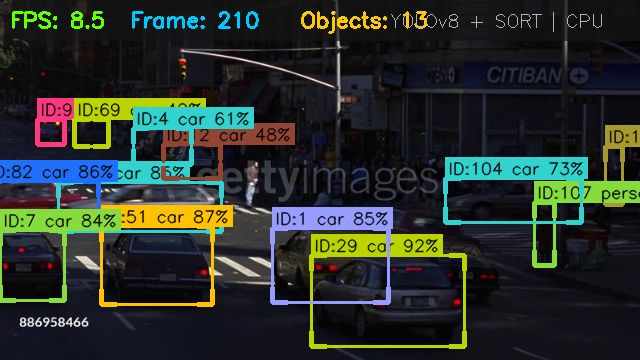

Frame 210 | FPS: 8.5 | Tracked: 13


KeyboardInterrupt: 

In [7]:
# ── Colors & Drawing ──
def get_color(track_id):
    colors=[(255,56,56),(255,157,151),(255,112,31),(255,178,29),(207,210,49),(72,249,10),
            (146,204,23),(61,219,134),(26,147,52),(0,212,187),(44,153,168),(0,194,255),
            (52,69,147),(100,115,255),(0,24,236),(132,56,255),(82,0,133),(203,56,255),(255,149,200),(255,55,199)]
    return colors[int(track_id)%len(colors)]

def draw_tracked_box(frame,x1,y1,x2,y2,track_id,label,conf):
    color=get_color(track_id); cv2.rectangle(frame,(x1,y1),(x2,y2),color,2)
    cl=15; th=3
    cv2.line(frame,(x1,y1),(x1+cl,y1),color,th); cv2.line(frame,(x1,y1),(x1,y1+cl),color,th)
    cv2.line(frame,(x2,y1),(x2-cl,y1),color,th); cv2.line(frame,(x2,y1),(x2,y1+cl),color,th)
    cv2.line(frame,(x1,y2),(x1+cl,y2),color,th); cv2.line(frame,(x1,y2),(x1,y2-cl),color,th)
    cv2.line(frame,(x2,y2),(x2-cl,y2),color,th); cv2.line(frame,(x2,y2),(x2,y2-cl),color,th)
    text=f"ID:{int(track_id)} {label} {conf:.0%}"
    (tw,th2),_=cv2.getTextSize(text,cv2.FONT_HERSHEY_SIMPLEX,0.55,1)
    cv2.rectangle(frame,(x1,y1-th2-8),(x1+tw+6,y1),color,-1)
    cv2.putText(frame,text,(x1+3,y1-4),cv2.FONT_HERSHEY_SIMPLEX,0.55,(0,0,0),1,cv2.LINE_AA)

def draw_hud(frame,fps,frame_num,total_tracks):
    h,w=frame.shape[:2]; overlay=frame.copy()
    cv2.rectangle(overlay,(0,0),(w,40),(20,20,20),-1); cv2.addWeighted(overlay,0.7,frame,0.3,0,frame)
    cv2.putText(frame,f"FPS: {fps:.1f}",(10,27),cv2.FONT_HERSHEY_SIMPLEX,0.7,(0,255,100),2)
    cv2.putText(frame,f"Frame: {frame_num}",(130,27),cv2.FONT_HERSHEY_SIMPLEX,0.7,(255,200,0),2)
    cv2.putText(frame,f"Objects: {total_tracks}",(300,27),cv2.FONT_HERSHEY_SIMPLEX,0.7,(0,200,255),2)
    cv2.putText(frame,"YOLOv8 + SORT | CPU",(w-250,27),cv2.FONT_HERSHEY_SIMPLEX,0.6,(180,180,180),1)

# ── Settings ──
USE_WEBCAM         = False
VIDEO_FILE_PATH    = "sample_video.mp4"
CONFIDENCE         = 0.35
CLASSES            = None          # None = all, [0] = people only, [0,2] = people+cars
MAX_FRAMES         = 300
RESIZE_WIDTH       = 640
OUTPUT_VIDEO_PATH  = "output_tracked.mp4"

# ── Download sample video if needed ──
if not USE_WEBCAM and not os.path.exists(VIDEO_FILE_PATH):
    print("Downloading sample video...")
    urllib.request.urlretrieve(
        "https://commondatastorage.googleapis.com/gtv-videos-bucket/sample/ForBiggerFun.mp4",
        VIDEO_FILE_PATH)
    print("✅ Downloaded!")
else:
    print("✅ Video ready!")

# ── Main Pipeline ──
KalmanBoxTracker.count=0
tracker=Sort(max_age=5,min_hits=2,iou_threshold=0.3)

cap=cv2.VideoCapture(RESIZE_WIDTH if USE_WEBCAM else VIDEO_FILE_PATH) if USE_WEBCAM else cv2.VideoCapture(VIDEO_FILE_PATH)
if not cap.isOpened(): raise RuntimeError("❌ Cannot open video!")

orig_w=int(cap.get(cv2.CAP_PROP_FRAME_WIDTH)); orig_h=int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))
fps_in=cap.get(cv2.CAP_PROP_FPS) or 30
proc_h=int(orig_h*(RESIZE_WIDTH/orig_w))
print(f"Video: {orig_w}x{orig_h} → processing at {RESIZE_WIDTH}x{proc_h}")

fourcc=cv2.VideoWriter_fourcc(*'mp4v')
writer=cv2.VideoWriter(OUTPUT_VIDEO_PATH,fourcc,fps_in,(RESIZE_WIDTH,proc_h))

frame_num=0; fps_display=0; t_start=time.time()

while True:
    ret,frame=cap.read()
    if not ret or (MAX_FRAMES and frame_num>=MAX_FRAMES): break
    frame_num+=1
    frame=cv2.resize(frame,(RESIZE_WIDTH,proc_h))

    t0=time.time()
    results=model(frame,conf=CONFIDENCE,classes=CLASSES,verbose=False,device='cpu')[0]
    dets=[]; det_labels={}
    if results.boxes is not None:
        for box in results.boxes:
            x1,y1,x2,y2=box.xyxy[0].cpu().numpy()
            conf=float(box.conf[0]); label=model.names[int(box.cls[0])]
            dets.append([x1,y1,x2,y2,conf])
            det_labels[((int(x1)+int(x2))//2,(int(y1)+int(y2))//2)]=(label,conf)

    dets_np=np.array(dets) if dets else np.empty((0,5))
    tracked=tracker.update(dets_np)

    for t in tracked:
        x1,y1,x2,y2,tid=int(t[0]),int(t[1]),int(t[2]),int(t[3]),int(t[4])
        tcx,tcy=(x1+x2)//2,(y1+y2)//2
        best_label,best_conf,best_dist="object",0.99,9999
        for (cx,cy),(lbl,cf) in det_labels.items():
            d=abs(cx-tcx)+abs(cy-tcy)
            if d<best_dist: best_dist=d; best_label,best_conf=lbl,cf
        draw_tracked_box(frame,x1,y1,x2,y2,tid,best_label,best_conf)

    fps_display=0.9*fps_display+0.1*(1.0/max(time.time()-t0,1e-4))
    draw_hud(frame,fps_display,frame_num,len(tracked))
    writer.write(frame)

    if frame_num%15==0:
        _,buf=cv2.imencode('.jpg',frame,[cv2.IMWRITE_JPEG_QUALITY,80])
        clear_output(wait=True)
        display(IPImage(data=buf.tobytes()))
        print(f"Frame {frame_num} | FPS: {fps_display:.1f} | Tracked: {len(tracked)}")

cap.release(); writer.release()
total_time=time.time()-t_start
clear_output(wait=True)
print("="*45)
print("✅ DONE!")
print(f"   Frames    : {frame_num}")
print(f"   Time      : {total_time:.1f}s")
print(f"   Avg FPS   : {frame_num/total_time:.1f}")
print(f"   Output    : {OUTPUT_VIDEO_PATH}")
print("="*45)